##### Lee, Keinath, Cianfarano and Brandon (2025). Identifying representational structure in CA1 to benchmark theoretical models of cognitive mapping. Neuron 113(2): 307-320. https://doi.org/10.1016/j.neuron.2024.10.027

In this notebook, we will run analyses and generate plots for panels from Figure 6, including the generation of spatial corresondence maps from population vector correlation of all spatial bins across pairs of geometries, population vector flow diagrams in example geometries illustrating the displacement of spatial coding following geometric deformation from a square environment, and direct comparison of spatial correspondence between model predictions and CA1 data.

First load in all packages and functions for analyses and plotting

In [18]:
from utils import *
from plots import *

Define path where georepca1 folder is located, including dataset manually added to the georepca1/data folder
e.g., r"Users/YourName/Documents/georepca1"

In [3]:
p = r"" # add path to georepca1 folder here
os.chdir(p)

Define list of animal IDs and example animal

In [4]:
animals = ['QLAK-CA1-08', 'QLAK-CA1-30', 'QLAK-CA1-50', 'QLAK-CA1-51', 'QLAK-CA1-56', 'QLAK-CA1-74', 'QLAK-CA1-75']

### Figure 6B
Calculate and plot similarity of all spatial bins in each pair of geometries for all spatially reliable cells and model features

In [7]:
# OPTIONAL. Warning - Long run time!
pv_matrix = get_pvcorr_pixelwise(animals, p)
joblib.dump(pv_matrix, os.path.join(p, "results", "pv_corr_pixelwise"))
# Now calculate same matrices for each model
sr_gamma = 0.999
sr_alpha = (50./30.)*10**(-3)
feature_types = ["PC", "GC2PC_th", f"PC2SF_{sr_gamma:.5f}gamma_{sr_alpha:.5f}alpha", "bt_GC2PC_th", "BVC2PC",
                 f"BVC2SF_{sr_gamma:.5f}gamma_{sr_alpha:.5f}alpha"]
feature_names = ["PC", "GC2PC", "PC2SF", "bt-GC2PC", "BVC2PC", "BVC2SF"]
for f, feature_type in enumerate(feature_types):
    pv_matrix = get_pvcorr_pixelwise(animals, p, feature_type)
    joblib.dump(pv_matrix, os.path.join(p, "results", "riab", f"pv_corr_pixelwise_{feature_type}"))

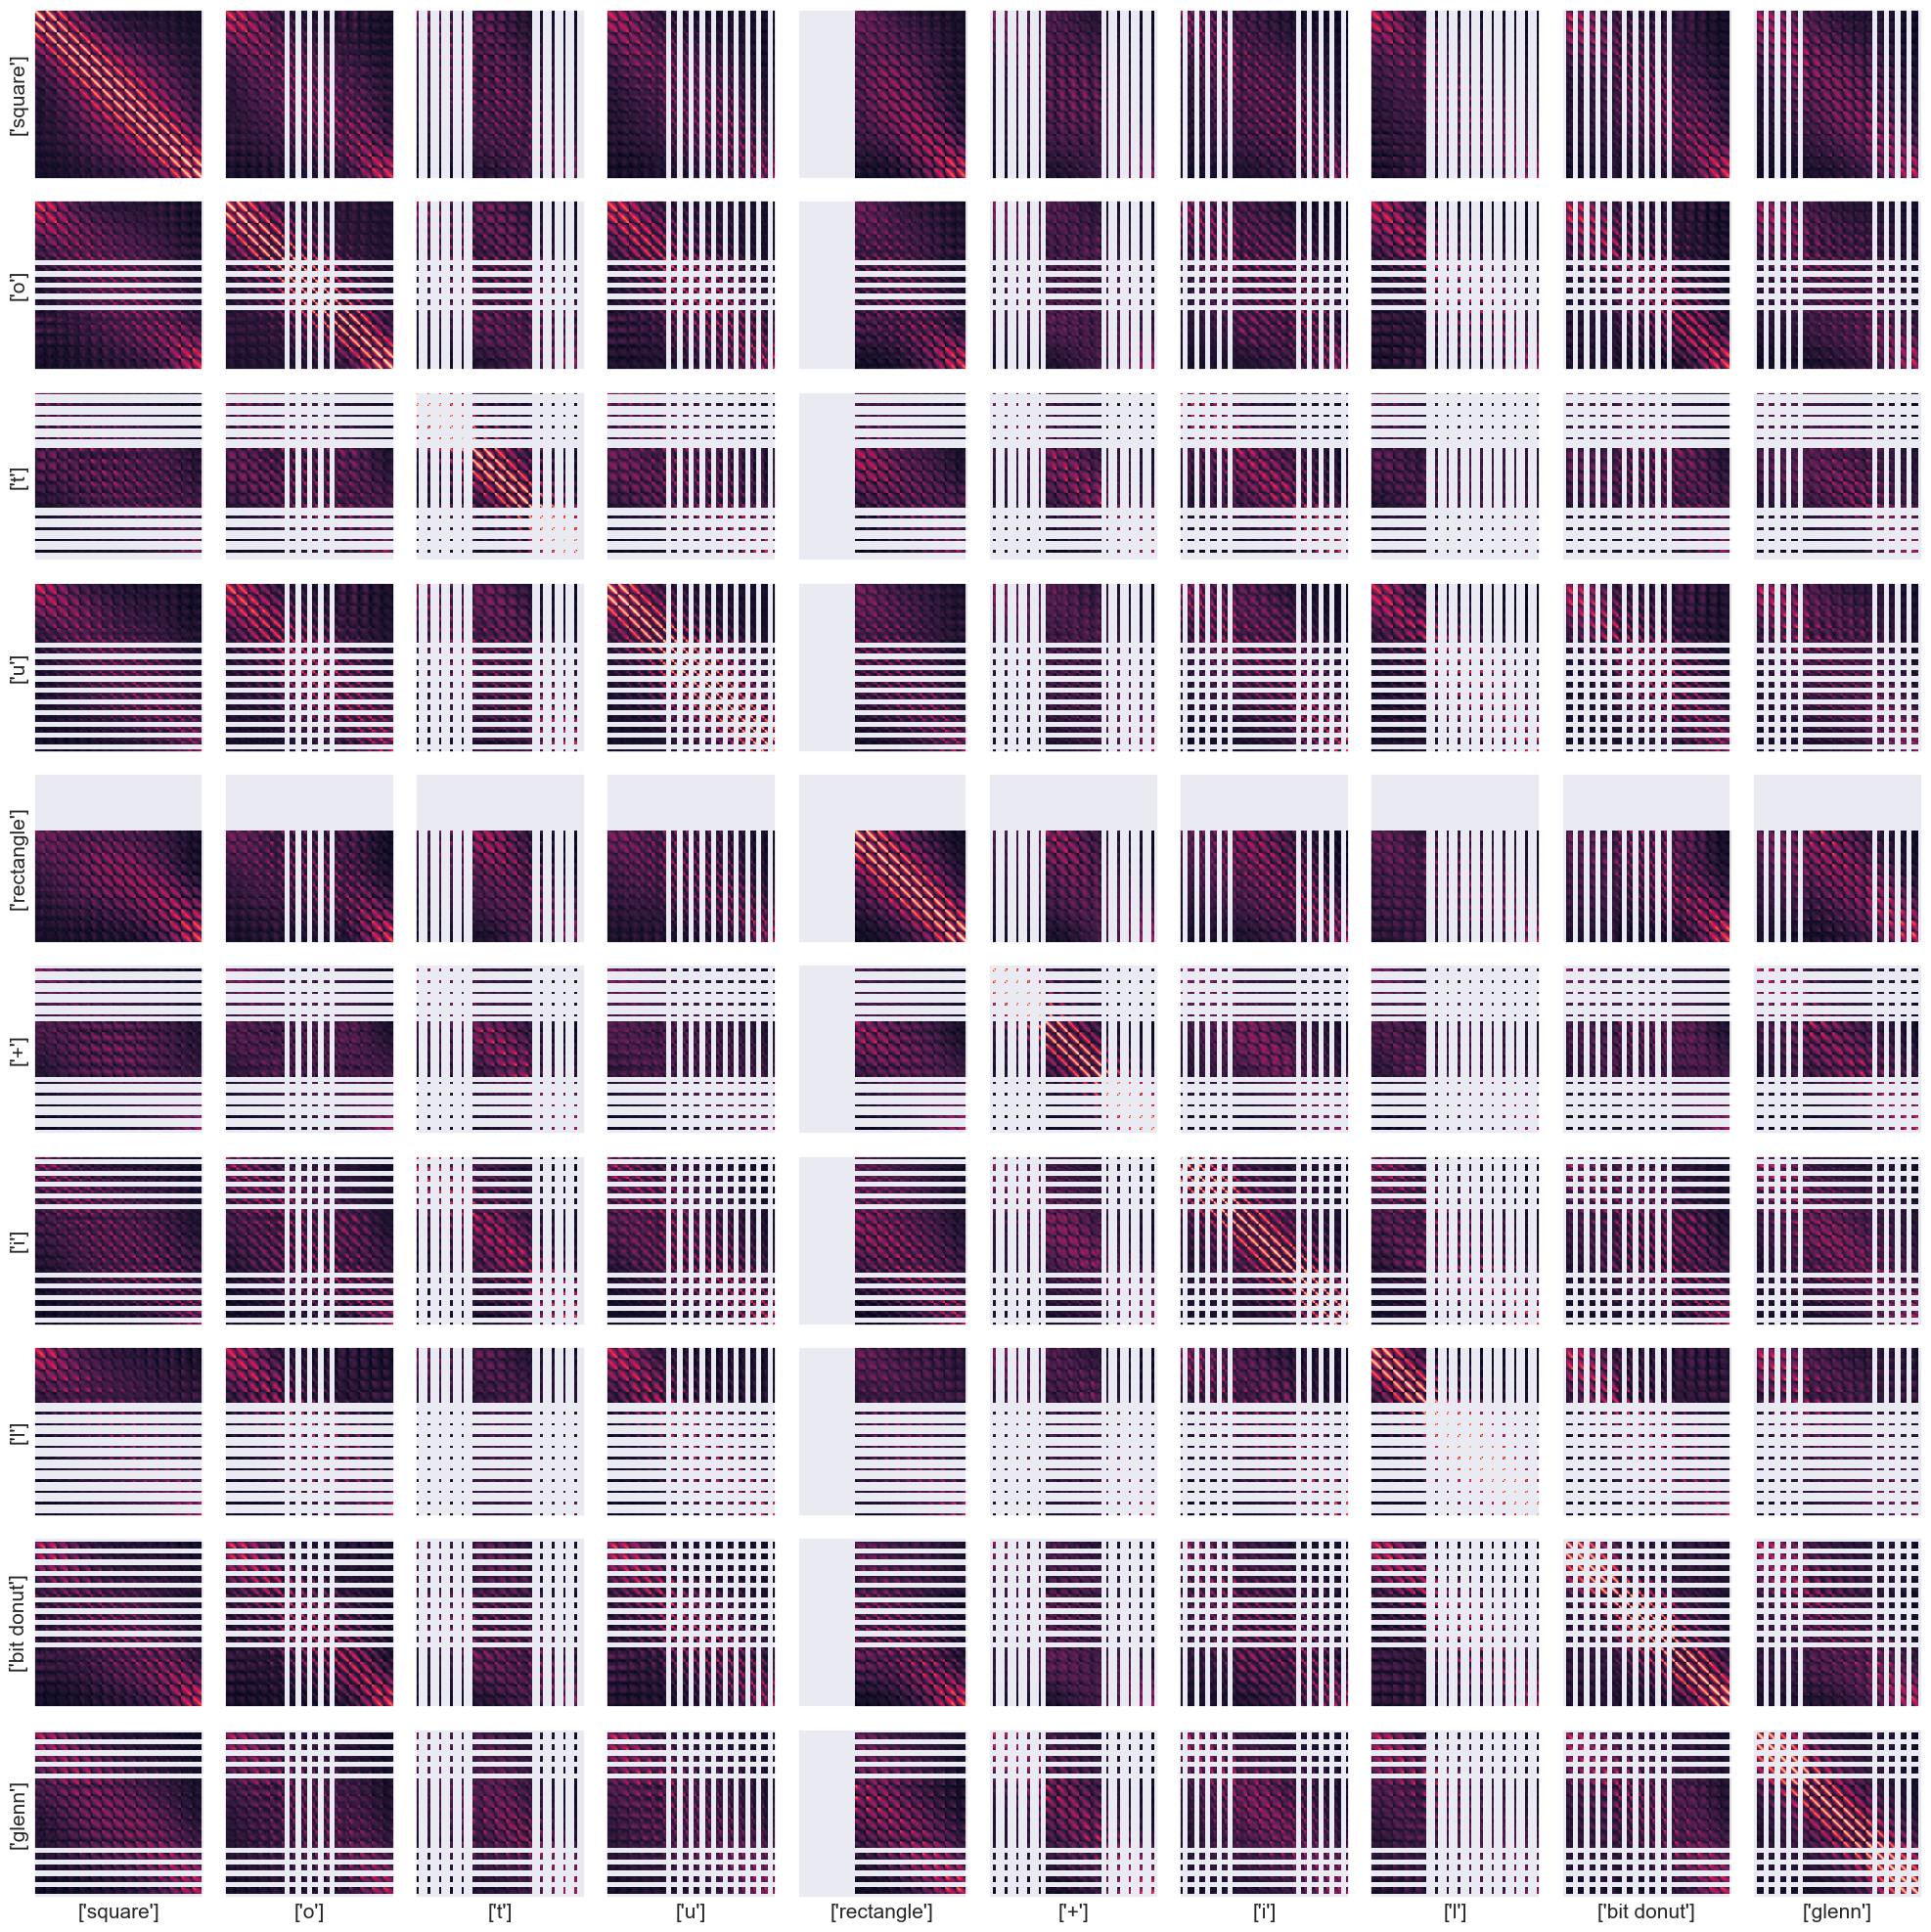

In [9]:
pv_matrix = joblib.load(os.path.join(p, "results", "pv_corr_pixelwise"))
fig_6b = plot_pv_matrix_pairwise(animals, pv_matrix, p)

### Figure 6D
Plot spatial correspondence maps showing similarity to seed location in environment A, and similarities to all locations in environment B

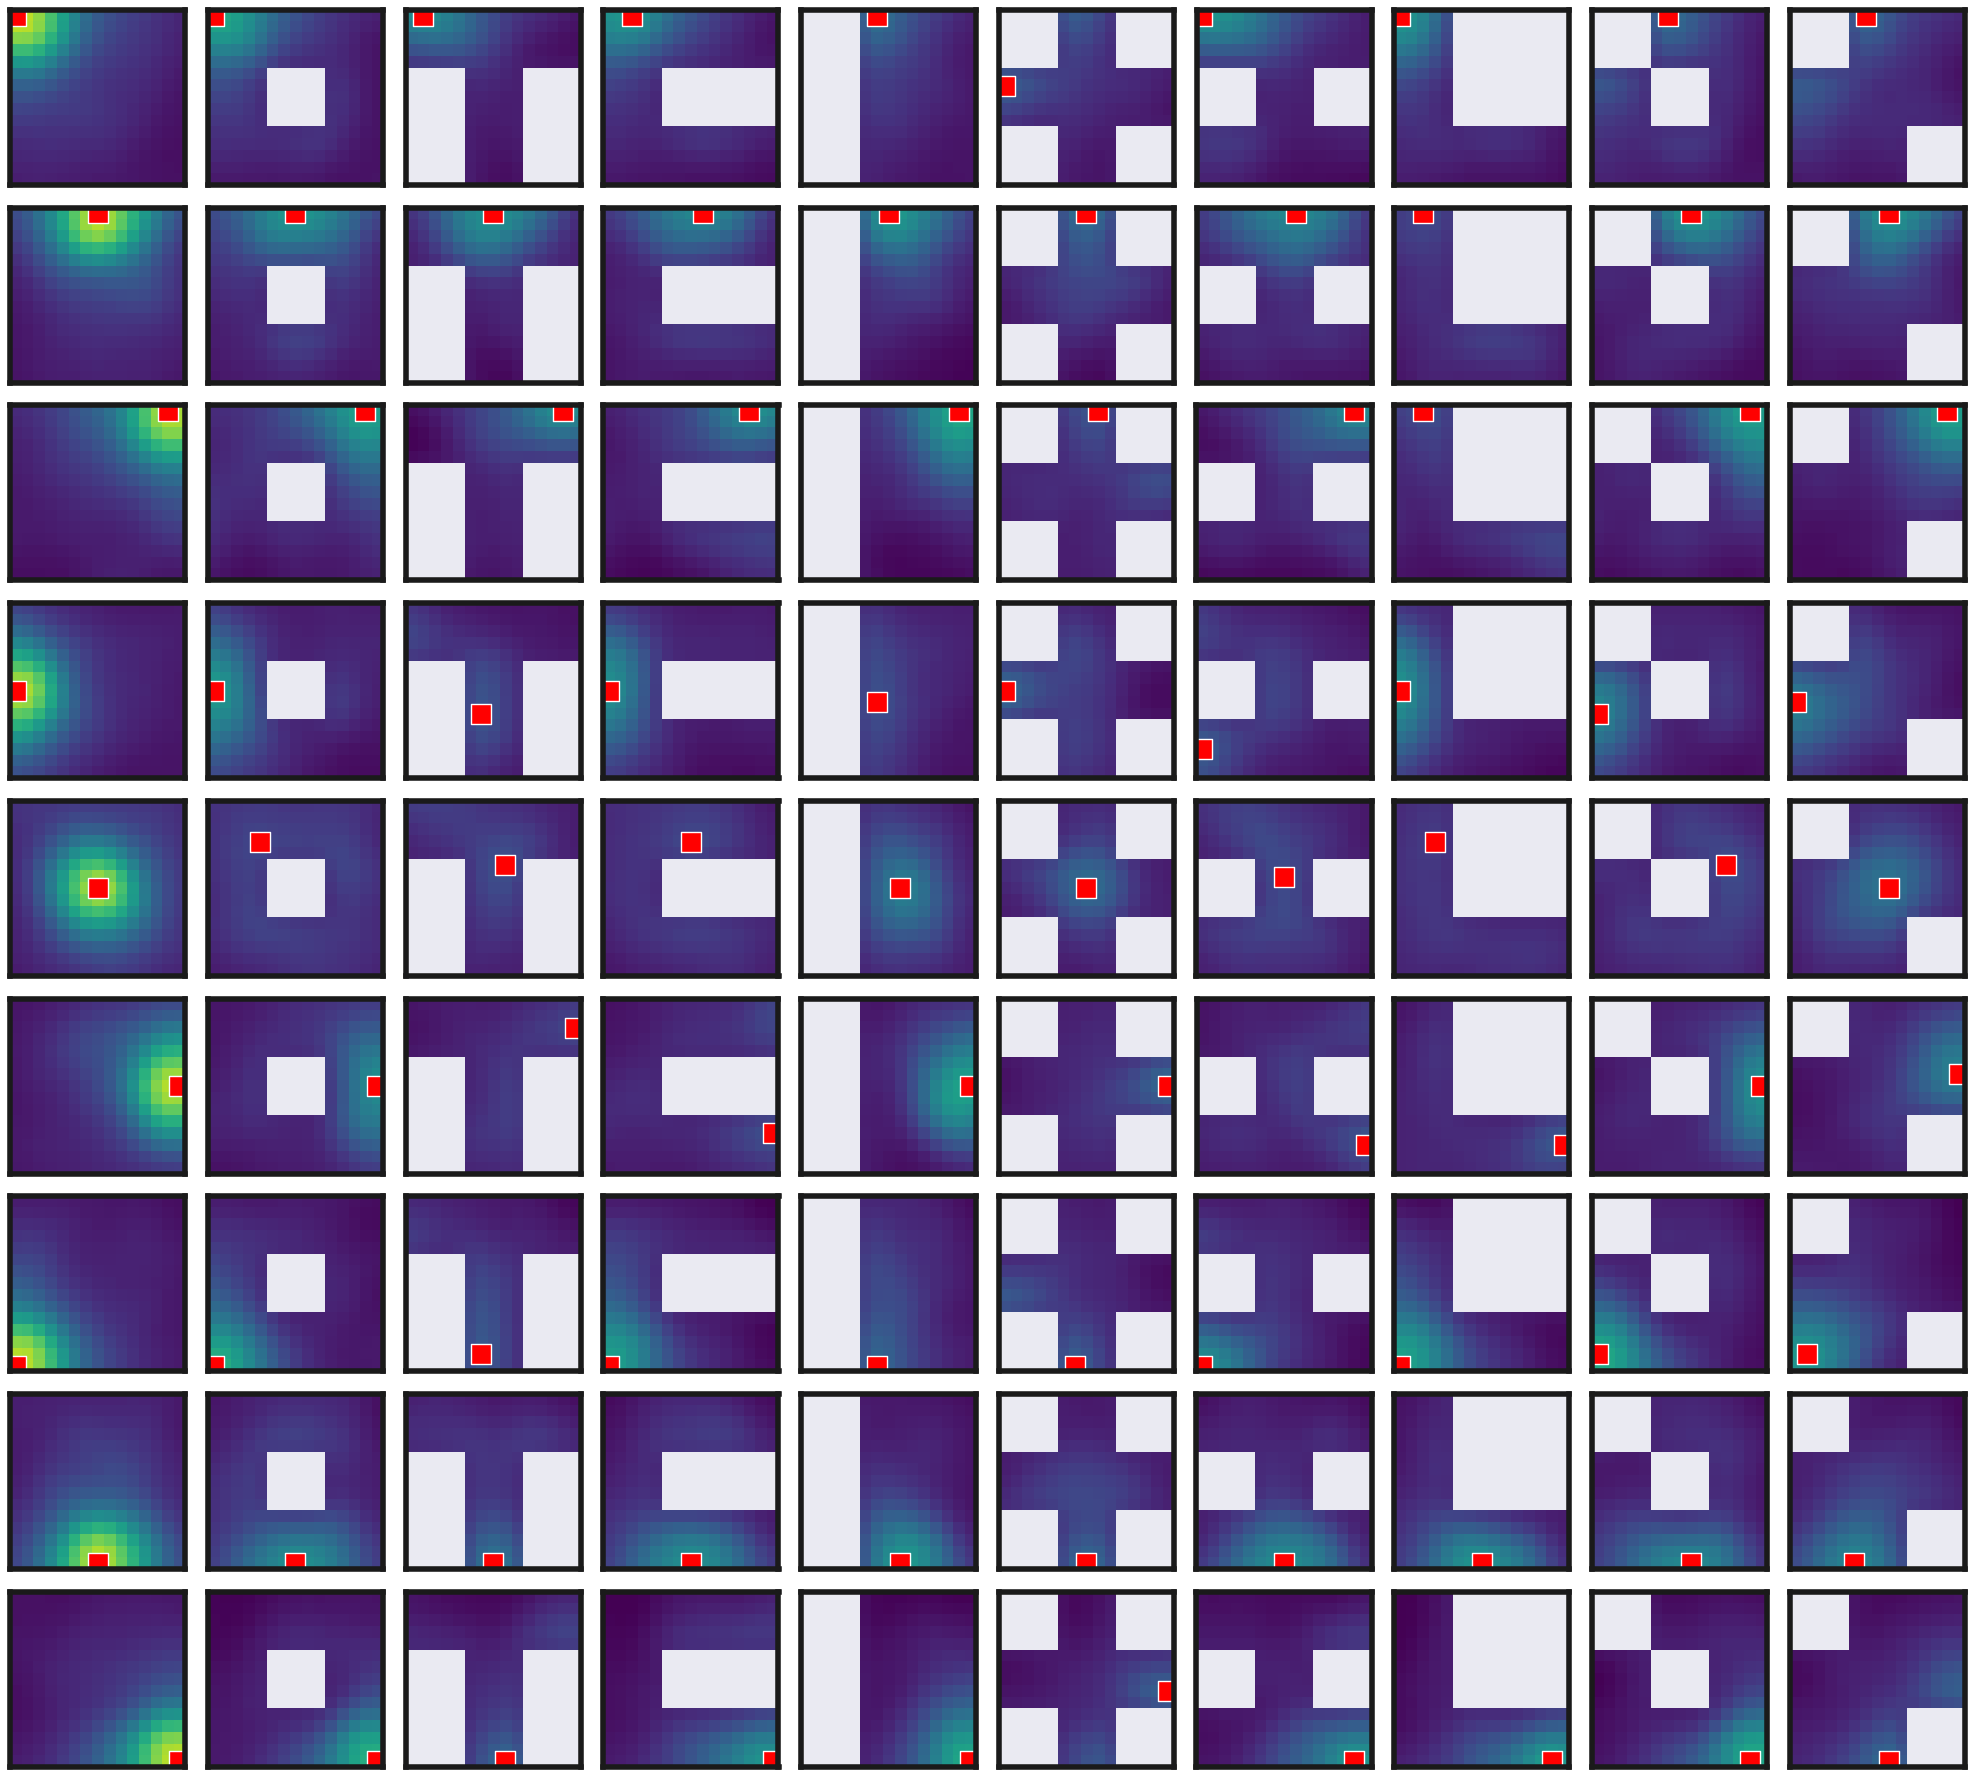

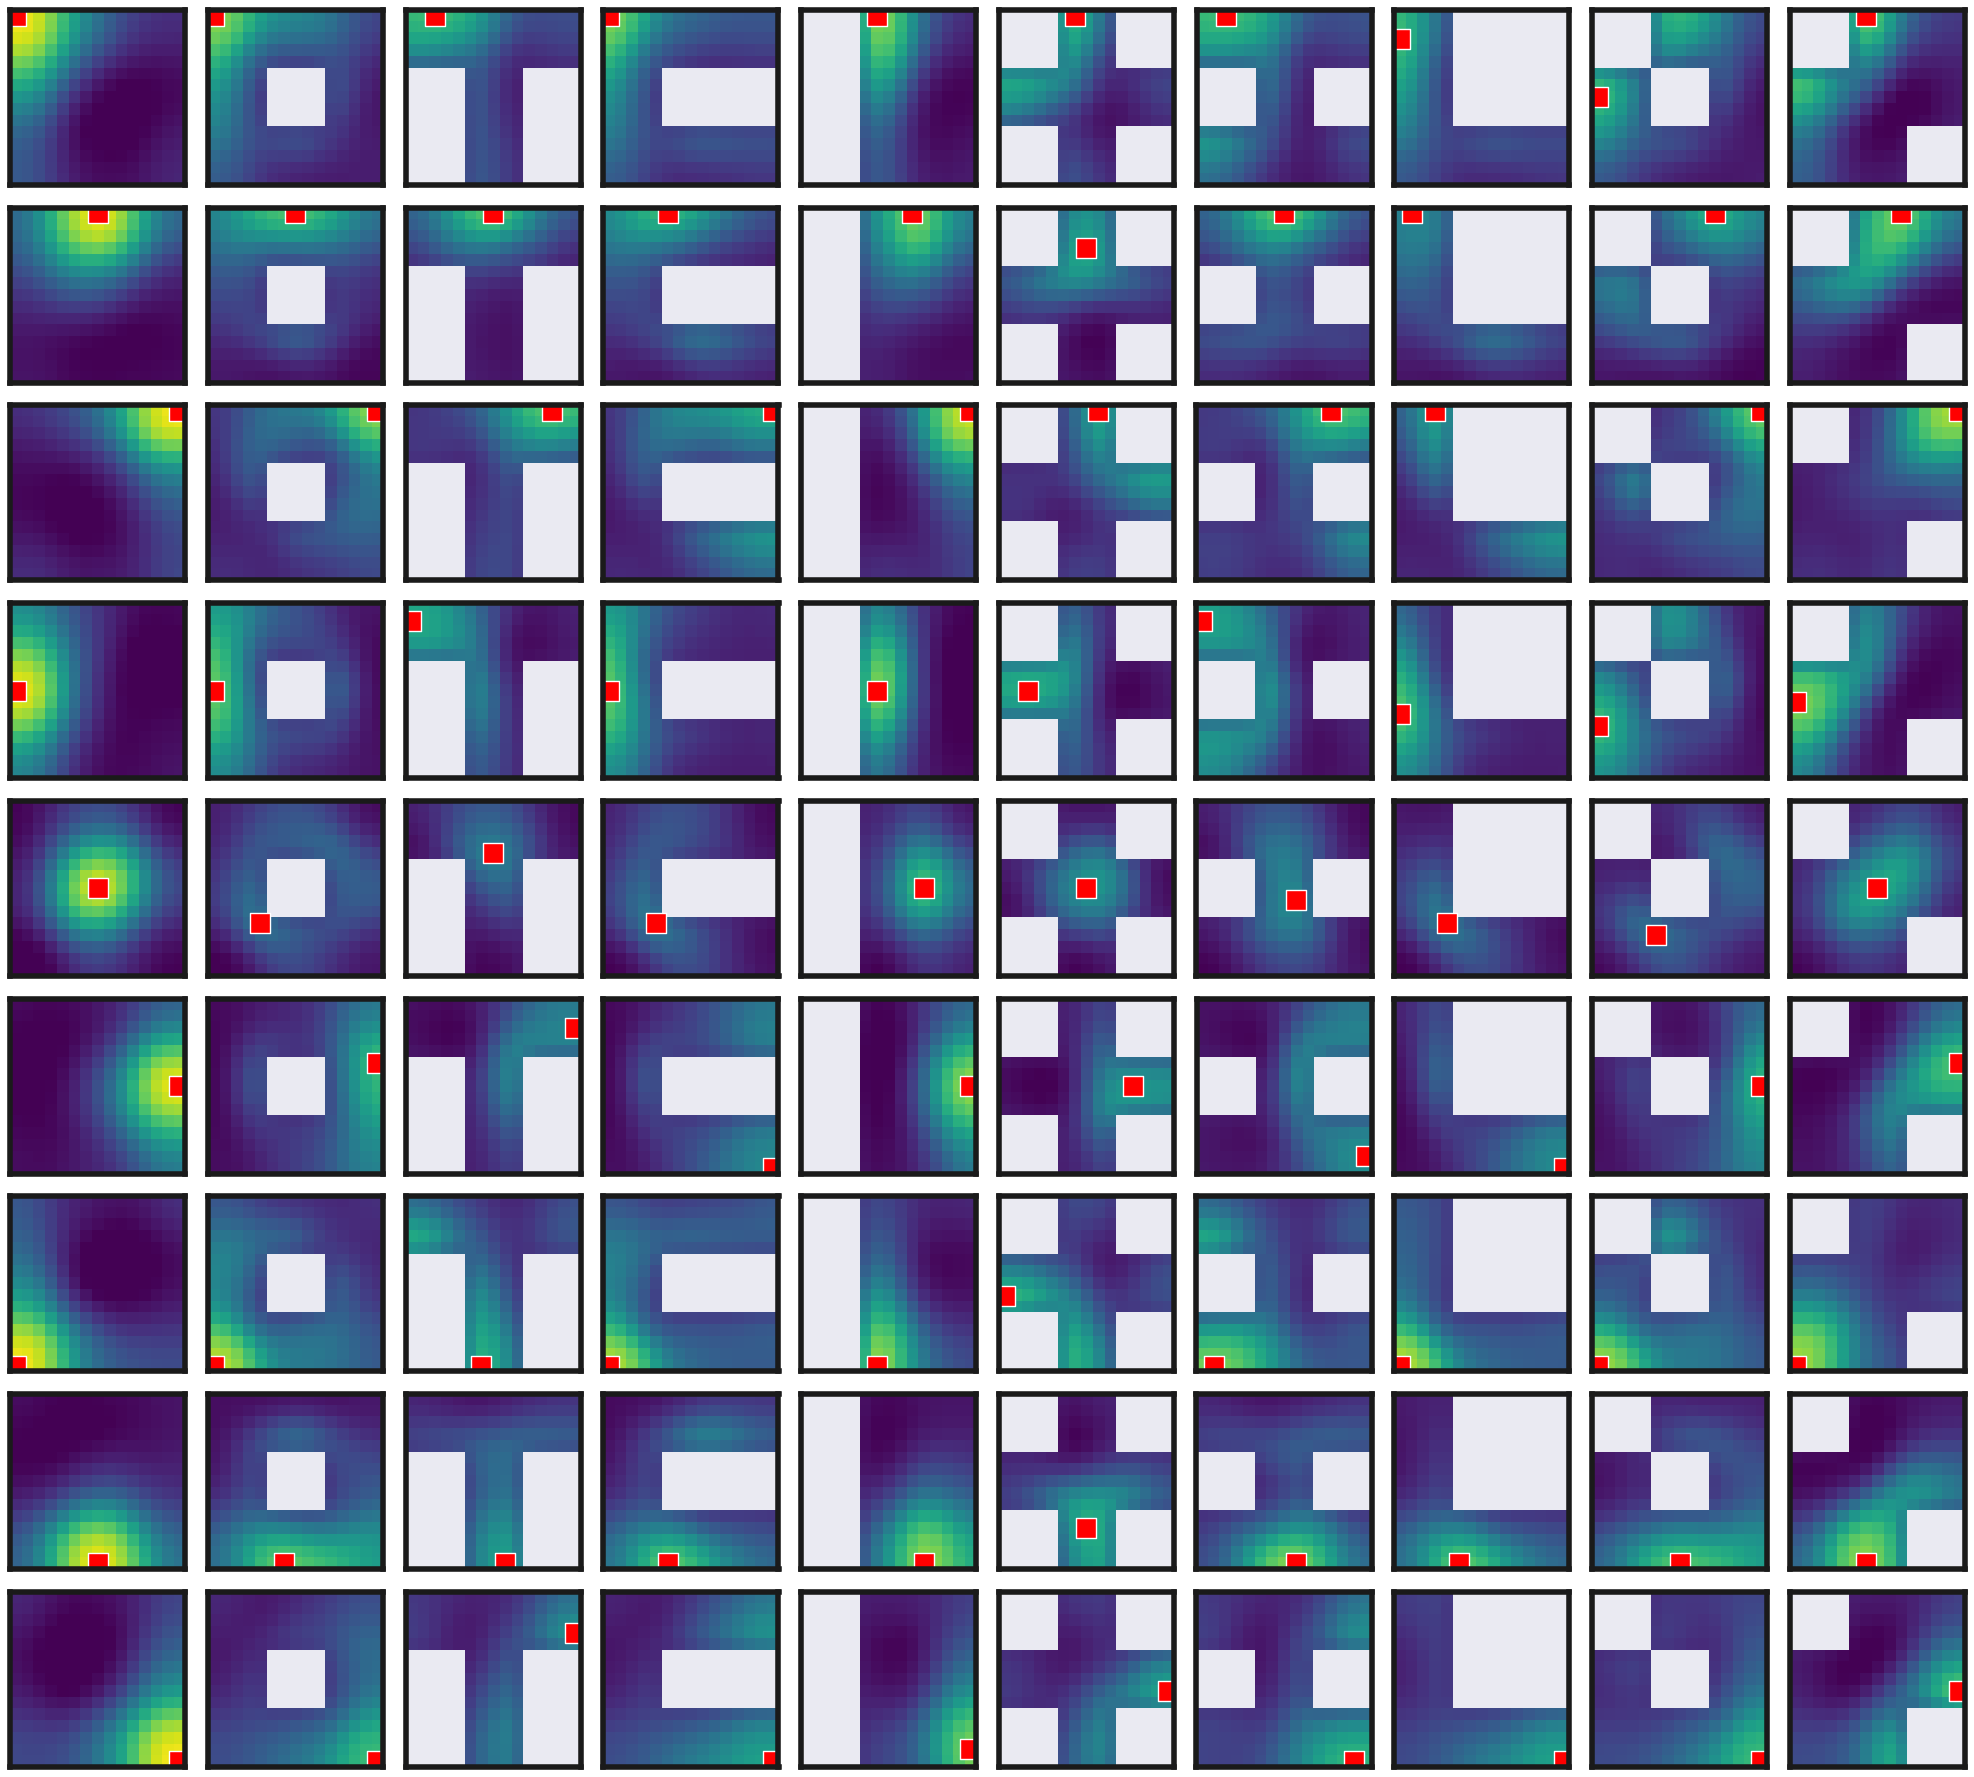

In [12]:
fig_6d1 = plot_spatial_correspondence(animals, p, None)
# Generate same plot for BVC2PC model results
fig_6d2 = plot_spatial_correspondence(animals, p, "BVC2PC")

### Figure 6E
Compute 2D vectors between each spatial bin in environment A and its most similar bin (max pv correlation) in example environment B and generate stream plots to show the flow of population vector fields

Loading preprocessed data for animal QLAK-CA1-08
Loading preprocessed data for animal QLAK-CA1-30
Loading preprocessed data for animal QLAK-CA1-50
Loading preprocessed data for animal QLAK-CA1-51
Loading preprocessed data for animal QLAK-CA1-56
Loading preprocessed data for animal QLAK-CA1-74
Loading preprocessed data for animal QLAK-CA1-75


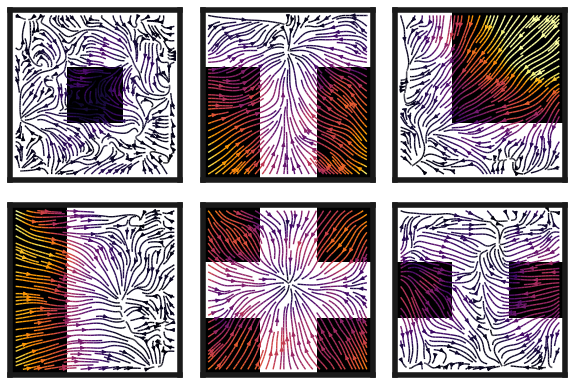

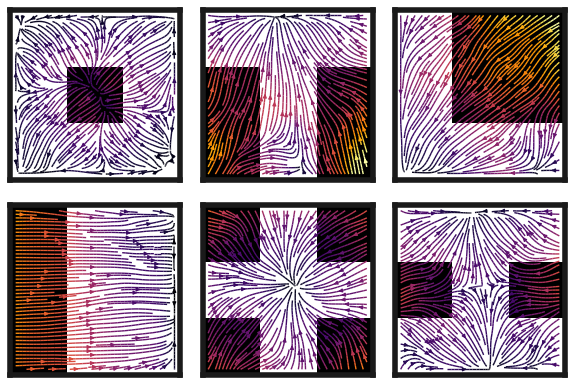

In [13]:
group_vector_fields, average_vector_fields, std_vector_fields = get_vector_fields_animals(animals, p)
fig_6E1 = plot_stream_vector_fields(group_vector_fields, average_vector_fields)
# Do the same for the BVC2PC model results
model_vector_fields, model_average_vector_fields, model_std_vector_fields = \
    get_vector_fields_animals(animals, p, feature_type="BVC2PC")
fig_6E2 = plot_stream_vector_fields(model_vector_fields, model_average_vector_fields)

### Figure 6F
Calculate fit to CA1 with pv correlation matrices as a pixel-wise RSM comparison (same principles as before with finer granularity of comparison)

In [ ]:
# OPTIONAL. Need to have computed SHR in first notebook!
pv_matrix_sequences = get_pvcorr_pixelwise(animals, p, average_result=False)
joblib.dump(pv_matrix_sequences, os.path.join(p, "results", "pv_corr_pixelwise_animals_sequences"))

6it [00:08,  1.42s/it]


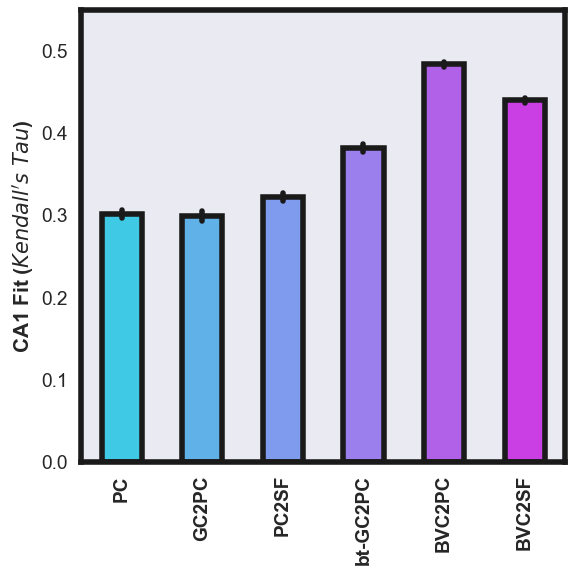

In [17]:
sr_gamma = 0.999
sr_alpha = (50./30.)*10**(-3)
feature_types = ["PC", "GC2PC_th", f"PC2SF_{sr_gamma:.5f}gamma_{sr_alpha:.5f}alpha", "bt_GC2PC_th", "BVC2PC",
                 f"BVC2SF_{sr_gamma:.5f}gamma_{sr_alpha:.5f}alpha"]
feature_names = ["PC", "GC2PC", "PC2SF", "bt-GC2PC", "BVC2PC", "BVC2SF"]
pv_matrix_sequences = np.nanmean(joblib.load(os.path.join(p, "results", "pv_corr_pixelwise_animals_sequences")), axis=0)
fig_6f = plot_ca1_model_correspondence(animals, pv_matrix_sequences, feature_names, feature_types, p)